# Dynamical Systems: Noisy Oscillator Quantum Reservoir Inference

Infer damping from sparse noisy oscillator traces using quantum reservoir regression and quantum Gaussian-process regression.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Estimate a damping coefficient from a few noisy displacement measurements.

**Explicit variables.** `gamma` is the target damping coefficient, `times` are measurement times, and `res_gamma_pred` contains reservoir estimates.

**Quantum advantage context.** Quantum reservoir features are a general nonlinear representation for short time-series windows. This notebook compares them with quantum GPR and ridge regression.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook generates underdamped oscillator traces with randomized damping and natural frequency.

In [2]:
def damped_oscillator_trace(gamma, omega0, times):
    omega_d = np.sqrt(np.maximum(omega0**2 - gamma**2, 1e-8))
    return np.exp(-gamma * times) * np.cos(omega_d * times)

rng = np.random.default_rng(701)
n_samples = 40
times = np.asarray([0.2, 0.7, 1.2, 1.7])
gamma = rng.uniform(0.05, 0.55, size=n_samples)
omega0 = rng.uniform(1.1, 1.8, size=n_samples)
traces = np.asarray([damped_oscillator_trace(g, w, times) for g, w in zip(gamma, omega0)])
traces += rng.normal(0.0, 0.025, size=traces.shape)

x_train, x_test, gamma_train, gamma_test = train_test_split(
    traces, gamma, test_size=0.3, random_state=701
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(gamma_train.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(gamma_test.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "damped oscillator damping inference"),
        ("Samples", n_samples),
        ("Features", [f"x(t={t})" for t in times]),
        ("Target", "damping coefficient gamma"),
    ],
)


Dataset
+----------+------------------------------------------+
| Metric   | Value                                    |
+----------+------------------------------------------+
| Problem  | damped oscillator damping inference      |
| Samples  | 40                                       |
| Features | [x(t=0.2), x(t=0.7), x(t=1.2), x(t=1.7)] |
| Target   | damping coefficient gamma                |
+----------+------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

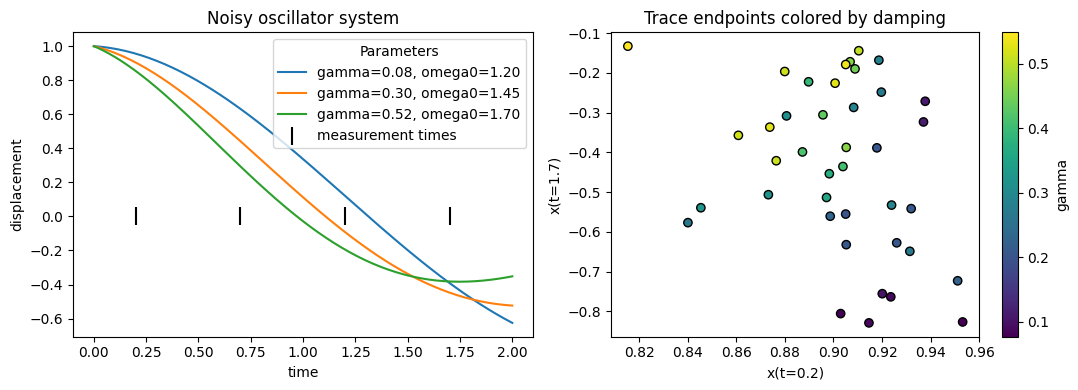

In [3]:
time_grid = np.linspace(0.0, 2.0, 160)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for g, w in [(0.08, 1.2), (0.30, 1.45), (0.52, 1.7)]:
    axes[0].plot(time_grid, damped_oscillator_trace(g, w, time_grid), label=f"gamma={g:.2f}, omega0={w:.2f}")
axes[0].scatter(times, np.zeros_like(times), marker="|", s=180, color="black", label="measurement times")
axes[0].set_title("Noisy oscillator system")
axes[0].set_xlabel("time")
axes[0].set_ylabel("displacement")
axes[0].legend(title="Parameters")
scatter = axes[1].scatter(traces[:, 0], traces[:, -1], c=gamma, cmap="viridis", edgecolor="black")
axes[1].set_title("Trace endpoints colored by damping")
axes[1].set_xlabel(f"x(t={times[0]})")
axes[1].set_ylabel(f"x(t={times[-1]})")
fig.colorbar(scatter, ax=axes[1], label="gamma")
plt.tight_layout()
plt.show()


## Package-client inverse models

In [4]:
reservoir = QuantumReservoirRegressor(
    QuantumReservoirFeatures(n_qubits=4, n_layers=2, seed=701),
    alpha=1e-3,
)
reservoir.fit(x_train, y_train)
res_gamma_pred = y_scaler.inverse_transform(reservoir.predict(x_test).reshape(-1, 1)).ravel()

qgpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="zz", seed=702), alpha=1e-3)
qgpr.fit(x_train, y_train)
gpr_gamma_pred = y_scaler.inverse_transform(qgpr.predict(x_test).reshape(-1, 1)).ravel()

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_gamma_pred = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "quantum_reservoir_gamma_mae": mean_absolute_error(gamma_test, res_gamma_pred),
    "quantum_gpr_gamma_mae": mean_absolute_error(gamma_test, gpr_gamma_pred),
    "ridge_gamma_mae": mean_absolute_error(gamma_test, ridge_gamma_pred),
}

print_section(
    "Results",
    [
        ("Quantum reservoir gamma MAE", results["quantum_reservoir_gamma_mae"]),
        ("Quantum GPR gamma MAE", results["quantum_gpr_gamma_mae"]),
        ("Ridge gamma MAE", results["ridge_gamma_mae"]),
    ],
)


Results
+-----------------------------+-----------+
| Metric                      | Value     |
+-----------------------------+-----------+
| Quantum reservoir gamma MAE | 0.112894  |
| Quantum GPR gamma MAE       | 0.114993  |
| Ridge gamma MAE             | 0.0389513 |
+-----------------------------+-----------+



## Plots

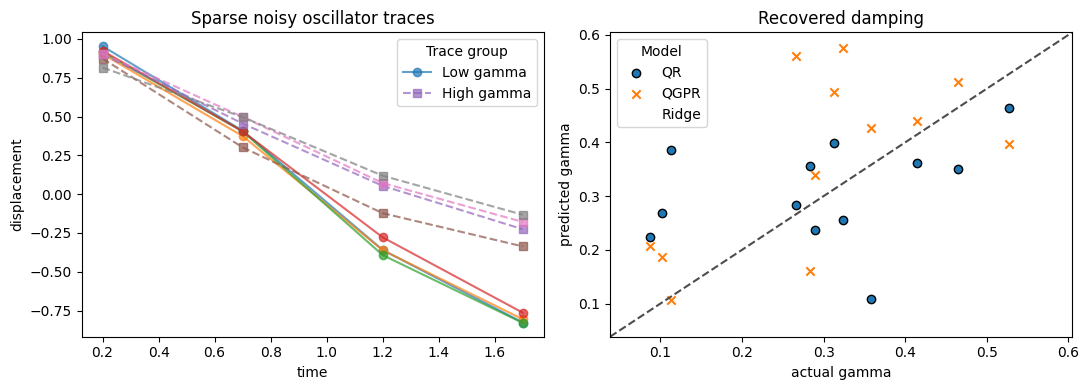

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
low_gamma = np.argsort(gamma)[:4]
high_gamma = np.argsort(gamma)[-4:]
for pos, idx in enumerate(low_gamma):
    axes[0].plot(times, traces[idx], "o-", alpha=0.7, label="Low gamma" if pos == 0 else None)
for pos, idx in enumerate(high_gamma):
    axes[0].plot(times, traces[idx], "s--", alpha=0.7, label="High gamma" if pos == 0 else None)
axes[0].set_title("Sparse noisy oscillator traces")
axes[0].set_xlabel("time")
axes[0].set_ylabel("displacement")
axes[0].legend(title="Trace group")

low = min(gamma_test.min(), res_gamma_pred.min(), gpr_gamma_pred.min(), ridge_gamma_pred.min()) - 0.03
high = max(gamma_test.max(), res_gamma_pred.max(), gpr_gamma_pred.max(), ridge_gamma_pred.max()) + 0.03
axes[1].scatter(gamma_test, res_gamma_pred, label="QR", edgecolor="black")
axes[1].scatter(gamma_test, gpr_gamma_pred, marker="x", label="QGPR")
axes[1].scatter(gamma_test, ridge_gamma_pred, marker="s", facecolors="none", label="Ridge")
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Recovered damping")
axes[1].set_xlabel("actual gamma")
axes[1].set_ylabel("predicted gamma")
axes[1].legend(title="Model")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "damped_oscillator_reservoir_inference",
        "n_train": int(len(gamma_train)),
        "n_test": int(len(gamma_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_gamma": float(a), "reservoir_gamma": float(r), "gpr_gamma": float(g)}
        for a, r, g in zip(gamma_test[:6], res_gamma_pred[:6], gpr_gamma_pred[:6])
    ],
    "passed": bool(
        np.isfinite(res_gamma_pred).all()
        and results["quantum_reservoir_gamma_mae"] < 0.25
        and results["quantum_gpr_gamma_mae"] < 0.25
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+---------------------------------------+
| Metric        | Value                                 |
+---------------+---------------------------------------+
| problem       | damped_oscillator_reservoir_inference |
| n_train       | 28                                    |
| n_test        | 12                                    |
| feature_count | 4                                     |
+---------------+---------------------------------------+

Results
+-----------------------------+-----------+
| Metric                      | Value     |
+-----------------------------+-----------+
| quantum_reservoir_gamma_mae | 0.112894  |
| quantum_gpr_gamma_mae       | 0.114993  |
| ridge_gamma_mae             | 0.0389513 |
+-----------------------------+-----------+

Sample predictions
+--------------+-----------------+-----------+
| actual_gamma | reservoir_gamma | gpr_gamma |
+--------------+-----------------+-----------+
| 0.087205     | 0.224281        | 0.20